# Basal melt in the Amundsen Sea

In [1]:
%matplotlib inline
import xarray as xr
import numpy as np
from dask.distributed import Client
import shutil as shutil
import netCDF4 as nc
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.dpi'] = 96
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["lines.linewidth"] = 1.5
plt.rcParams["lines.markersize"] = 3
plt.rcParams['hatch.color'] = 'k'
plt.rcParams["savefig.facecolor"] = 'white'

In [3]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42995,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33731,Total threads: 4
Dashboard: /proxy/35751/status,Memory: 35.88 GiB
Nanny: tcp://127.0.0.1:36501,


## Load data

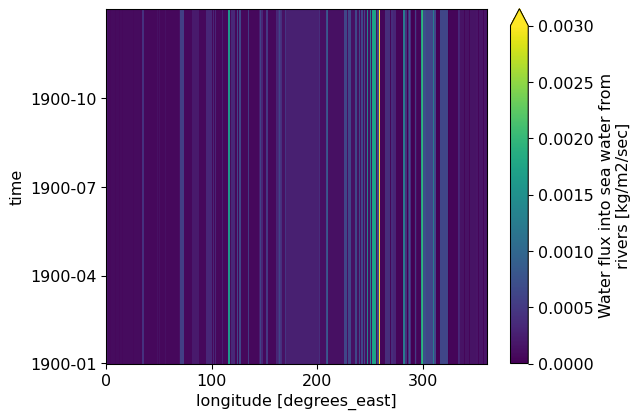

In [4]:
runoff = xr.open_dataarray(
    '/g/data/ik11/inputs/JRA-55/RYF/v1-3/RYF.runoff_all.1990_1991.nc')
runoff = runoff.where(runoff != 0)
runoff.sel(latitude=slice(-80, -60)).sum('latitude').plot(vmax=0.003);

In [5]:
# convert to common units
lat_length = np.ones((len(runoff.latitude), len(runoff.longitude)))*111/4*1e3 # make sure it's in m
lat_grid = np.pi/180*np.array([runoff.latitude.values]*len(runoff.longitude)).transpose()
lon_length = lat_length * np.cos(lat_grid)
area_grid = lat_length * lon_length
area_grid = xr.DataArray(area_grid, dims=['latitude', 'longitude'],
                         coords=[runoff.latitude, runoff.longitude])

## Save meltwater forcing decreased by 50%

In [6]:
change_perc = 0.50
runoff_addition = change_perc*runoff.where(
    (runoff.latitude <= -70) &
    (runoff.longitude >= 210) & (runoff.longitude <= 272), 0)
runoff_modified = runoff - runoff_addition

control runoff in Amundsen Sea in Gt/yr: 796
modified runoff in Amundsen Sea in Gt/yr: 398
globally summed difference in runoff compared to control in Gt/yr: -398


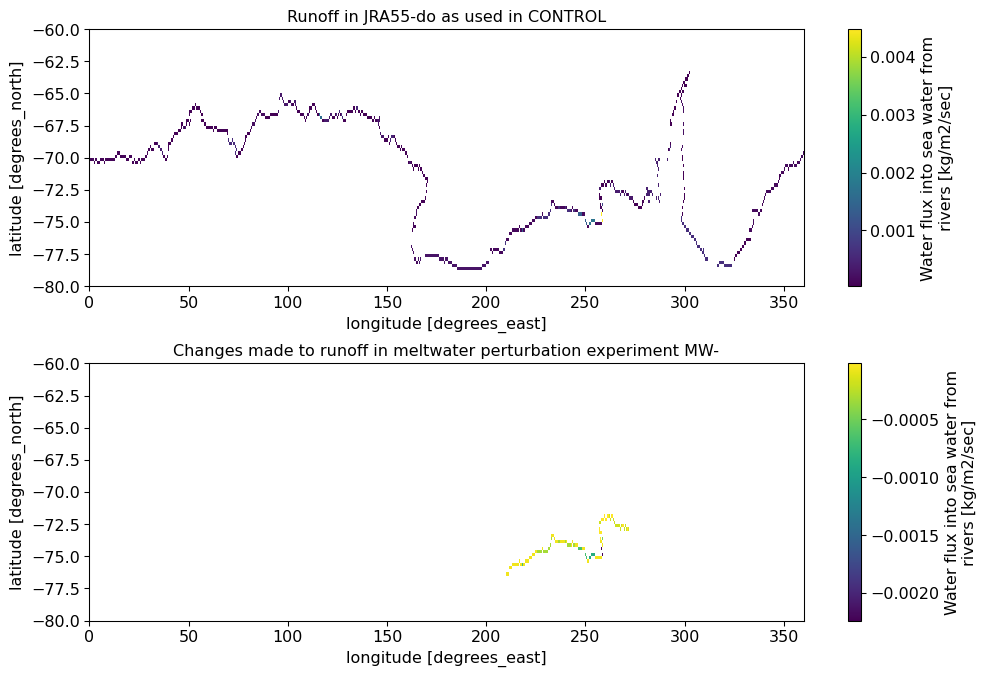

In [7]:
plt.figure(figsize=(12, 8))
plt.subplots_adjust(hspace=.3)
plt.subplot(2, 1, 1)
runoff.sel(latitude=slice(-80, -60))[0, :].plot()
plt.title('Runoff in JRA55-do as used in CONTROL')
plt.subplot(2, 1, 2)
(runoff_modified - runoff).where((runoff_modified - runoff) != 0).sel(
    latitude=slice(-80, -60))[0, :].plot()
plt.title('Changes made to runoff in meltwater perturbation experiment MW-')
print('control runoff in Amundsen Sea in Gt/yr: ' + str(int(
    (runoff.where(
    (runoff.latitude <= -70) &
    (runoff.longitude >= 210) & (runoff.longitude <= 272))*
     area_grid*(60*60*24*365)*1e-12)[0, :].sum())))
print('modified runoff in Amundsen Sea in Gt/yr: ' +
     str(int((runoff_addition*area_grid*(60*60*24*365)*1e-12)[0, :].sum())))
print('globally summed difference in runoff compared to control in Gt/yr: ' +
     str(int(((runoff_modified - runoff)*area_grid*(60*60*24*365)*1e-12)[0, :].sum())))

In [8]:
""" to save dataset with constant runoff modification """ 
# to ensure metadata etc is correct, copy old files and overwrite data:

# original files:
mw_file = '/g/data/ik11/inputs/JRA-55/RYF/v1-3/RYF.runoff_all.1990_1991.nc'
path_output = '/g/data/e14/cs6673/Ross_salinity/forcing_perturbed/'

###### Save perturbed meltwater fields
# new file names:
new_file = path_output + 'RYF_mw_decreased_' + str(int(change_perc*100)) + '.runoff_all.1990_1991.nc'
# copy old files into new file paths:
shutil.copyfile(mw_file, new_file)
# then overwrite the variables in the new files with the new data:
ncFile = nc.Dataset(new_file, 'r+')
ncFile.variables['friver'][...] = runoff_modified.values
ncFile.close()